In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from collections import Counter
import seaborn as sns
from matplotlib import pyplot as plt

import pickle
import glob
import os

<Figure size 100x100 with 0 Axes>

In [2]:
from annot import *
from utils import get_annotation
annotationdf = get_annotation()

# prepare depmap data

In [ ]:
from context import prepare_depmap_scores
prepare_depmap_scores(annotationdf, ensmbl_df)

In [ ]:
from context import count_depmap_celllines
count_depmap_celllines()

# 4A-B, S3: depmap plot

In [3]:
from manuscript import aggregate_depmap_figdata
df1 = aggregate_depmap_figdata(panel_option='top') #cats vs reference
df2 = aggregate_depmap_figdata(panel_option='de') # cats vs DE
df3 = aggregate_depmap_figdata(panel_option='hpa') # cats vs hpa
df4 = aggregate_depmap_figdata(panel_option='retained') # retain vs discard

df1.to_csv(f'{PROJECT_location}/depmap/depmap_summary_cats_panel.csv', header=True, index=True)
df2.to_csv(f'{PROJECT_location}/depmap/depmap_summary_de_panel.csv', header=True, index=True)
df3.to_csv(f'{PROJECT_location}/depmap/depmap_summary_frost_panel.csv', header=True, index=True)
df4.to_csv(f'{PROJECT_location}/depmap/depmap_summary_retained_panel.csv', header=True, index=True)


682

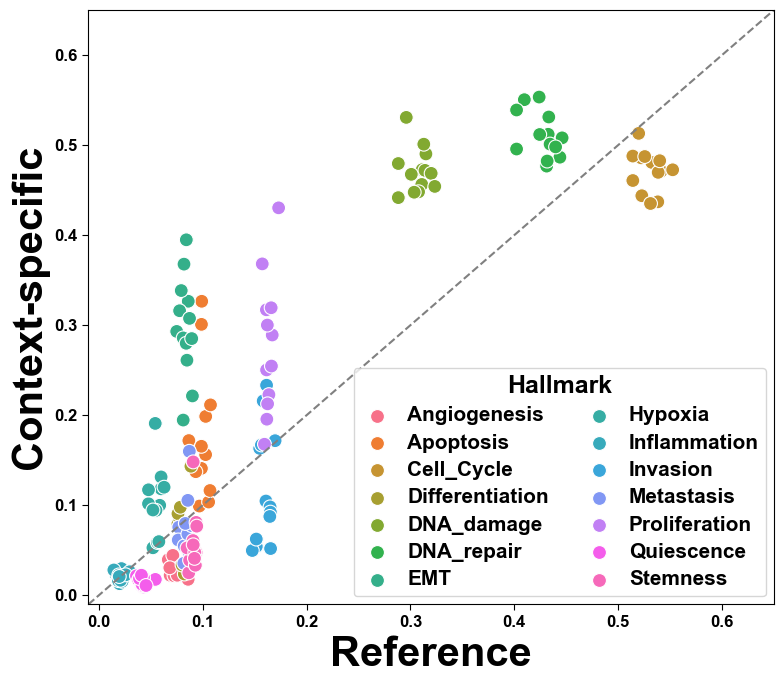

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8,7), tight_layout=True) #
ax = axes

sns.scatterplot(ax=ax, data=df1, x='context-agnostic', y='context-specific', hue='hallmark', s=100, alpha=1)  
ax.tick_params(axis='y', rotation=0)
ax.set_ylabel('Context-specific', fontsize='30', fontweight='bold')
ax.set_xlabel('Reference', fontsize='30', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='lower right', ncol=2, title="Hallmark")
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
ax.set_xlim(-0.01, 0.65)
ax.set_ylim(-0.01, 0.65)
fig.savefig(f'{PROJECT_location}/Figures/Fig_4A_depmap.png', dpi=700)


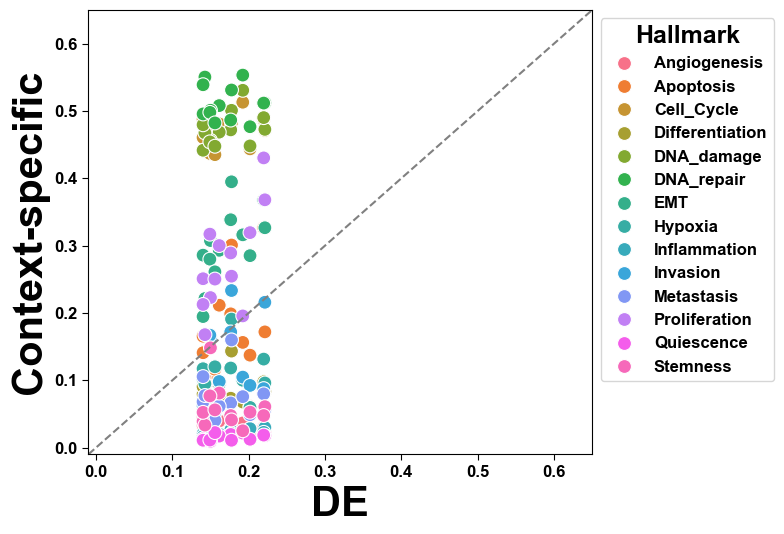

In [117]:
fig, axes = plt.subplots(1, 1, figsize=(8,5.5), tight_layout=True) #
ax = axes

sns.scatterplot(ax=ax, data=df2, x='context-agnostic', y='context-specific', hue='hallmark', s=100, alpha=1)  
ax.tick_params(axis='y', rotation=0)
ax.set_ylabel('Context-specific', fontsize='30', fontweight='bold')
ax.set_xlabel('DE', fontsize='30', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='lower right', ncol=2, title="Hallmark")
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
ax.set_xlim(-0.01, 0.65)
ax.set_ylim(-0.01, 0.65)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)); 
fig.savefig(f'{PROJECT_location}/Figures/Fig_S3A_depmap.png', dpi=700)

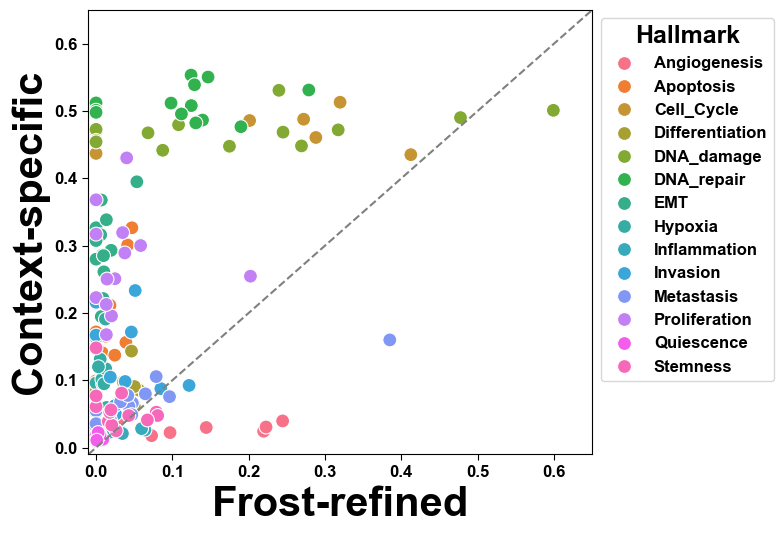

In [110]:
fig, axes = plt.subplots(1, 1, figsize=(8,5.5), tight_layout=True) #

ax = sns.scatterplot(ax=axes, data=df3, x='context-agnostic', y='context-specific', hue='hallmark', s=100, alpha=1)  
ax.tick_params(axis='y', rotation=0)
ax.set_ylabel('Context-specific', fontsize='30', fontweight='bold')
ax.set_xlabel('Frost-refined', fontsize='30', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='lower right', ncol=2, title="Hallmark")
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
ax.set_xlim(-0.01, 0.65)
ax.set_ylim(-0.01, 0.65)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)); 
fig.savefig(f'{PROJECT_location}/Figures/Fig_S3B_depmap.png', dpi=700)

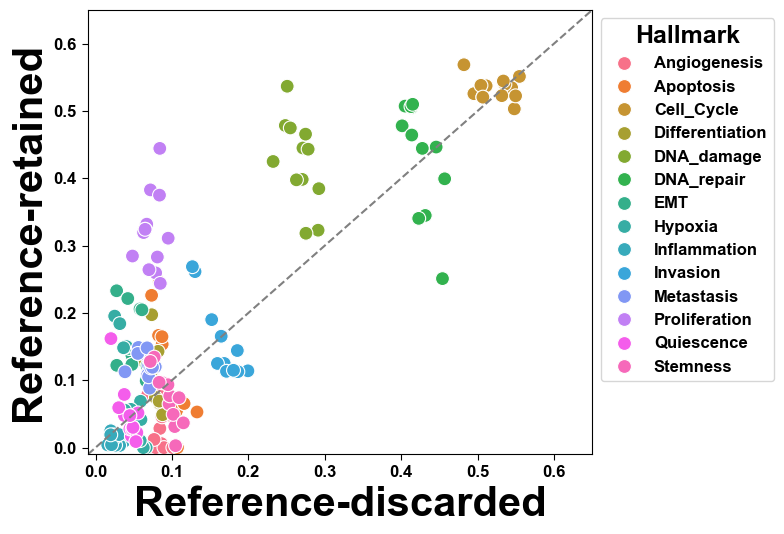

In [113]:
fig, axes = plt.subplots(1, 1, figsize=(8,5.5), tight_layout=True) #

ax = sns.scatterplot(ax=axes, data=df4, x='context-agnostic', y='context-specific', hue='hallmark', s=100, alpha=1)  
ax.tick_params(axis='y', rotation=0)
ax.set_ylabel('Reference-retained', fontsize='30', fontweight='bold')
ax.set_xlabel('Reference-discarded', fontsize='30', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')
ax.legend(loc='lower right', ncol=2, title="Hallmark")
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
ax.set_xlim(-0.01, 0.65)
ax.set_ylim(-0.01, 0.65)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1)); 

fig.savefig(f'{PROJECT_location}/Figures/Fig_S3C_depmap.png', dpi=700)


# Fig 4C-D, S4: cancer risk loci

In [ ]:
from context import count_cancer_risk_loci

count_cancer_risk_loci()

In [118]:
from context import run_gwas_overlaps
run_gwas_overlaps(annotationdf)

PRAD Prostate cancer
BRCA Breast cancer
COAD Colorectal cancer
LGG Glioma
GBM Glioma
LUSC Lung cancer
LUAD Lung cancer
OV Ovarian cancer
SKCM Melanoma
PAAD Pancreatic cancer
ESCA Esophageal cancer
BLCA Bladder cancer
THCA Thyroid cancer


93 14 75 182
0.03364970734070453 -0.0045744765026854385
WilcoxonResult(statistic=9773.0, pvalue=1.1257155921345861e-05)


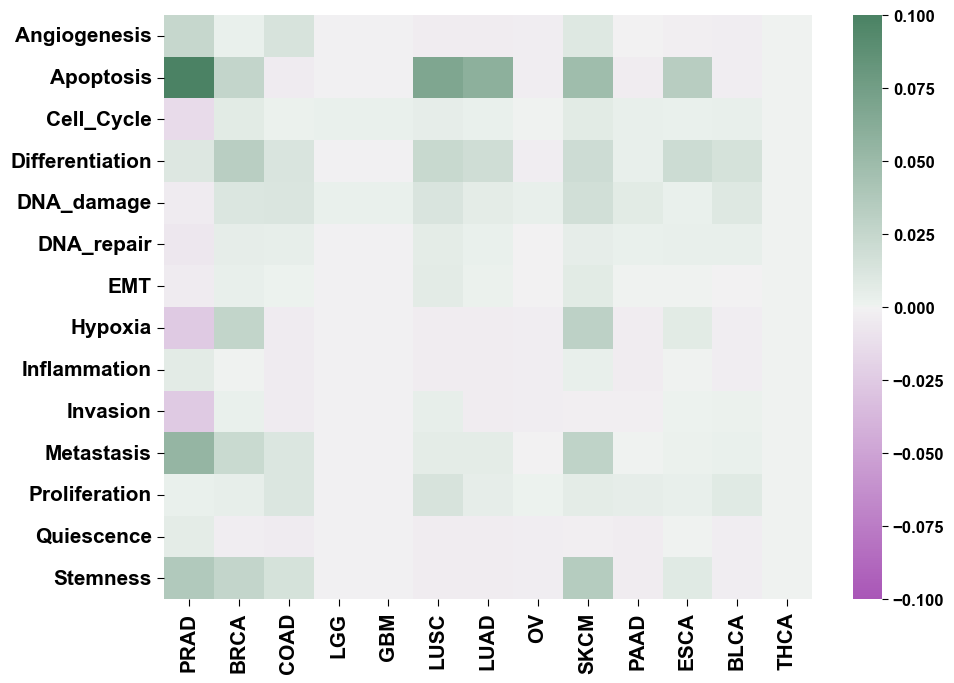

In [4]:
from manuscript import plot_risk_loci_overlaps
from scipy.stats import mannwhitneyu
scatterdf = plot_risk_loci_overlaps('Context', 'context', 'Reference', 'original', '4D_gwas')
scatterdf_ = plot_risk_loci_overlaps('Context', 'context', 'DE', 'de', 'S4A_gwas')
scatterdf_ = plot_risk_loci_overlaps('Context', 'context', 'Frost-refined', 'hpa', 'S4B_gwas')
scatterdf_ = plot_risk_loci_overlaps('Reference-retained', 'retain', 'Reference-discarded', 'discard', 'S4C_gwas')

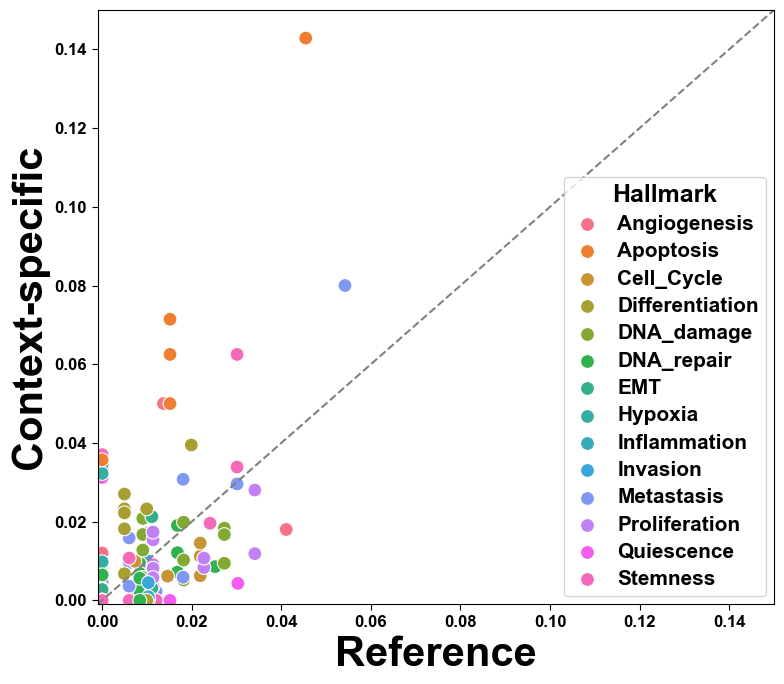

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(8,7), tight_layout=True) #
ax = sns.scatterplot(ax=axes, data=scatterdf, x='Original', y='Context', hue='Hallmark', s=100, alpha=1)
ax.set_ylim((-0.001, 0.15))
ax.set_xlim((-0.001, 0.15))
ax.set_ylabel('Context-specific', fontsize='30', fontweight='bold')
ax.set_xlabel('Reference', fontsize='30', fontweight='bold')
ax.axline((0,0), slope=1, color='grey', linestyle='--')

ax.legend(loc='lower right', ncol=1, title="Hallmark")
plt.setp(ax.get_legend().get_texts(), fontsize='15') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='18')
fig.savefig(f'{PROJECT_location}/Figures/Fig_4C_cancerrisk.png', dpi=700)